In [1]:
import matplotlib.pyplot as plt
import numpy as np
from notebook_utils import load_data
from cns.process.cluster import get_breaks, breaks_to_clusters, merge_clusters, created_merged_segs
from cns.utils.assemblies import hg19

# auto reload modules
%load_ext autoreload
%autoreload 2

# set non-transparent background for plots
plt.rcParams['figure.facecolor'] = 'white'

In [2]:
data = load_data()
pcawg = data['PCAWG'].cns

In [3]:
dict_start = get_breaks(pcawg)
print("Breakpoints per chromosome:")
for key, value in dict_start.items():
    print("*", key, len(value))
print("Total breakpoints:", sum([len(value) for value in dict_start.values()]))

Breakpoints per chromosome:
* chr1 28035
* chr10 12326
* chr11 19215
* chr12 21812
* chr13 8435
* chr14 8759
* chr15 6998
* chr16 9163
* chr17 15160
* chr18 8930
* chr19 11775
* chr2 20962
* chr20 8967
* chr21 4951
* chr22 5171
* chr3 21521
* chr4 15212
* chr5 17847
* chr6 20231
* chr7 18365
* chr8 21897
* chr9 13272
* chrX 9956
* chrY 200
Total breakpoints: 329160


Text(0.5, 1.0, 'Merged breakpoints distribution in chromosome 1, distance 25kb')

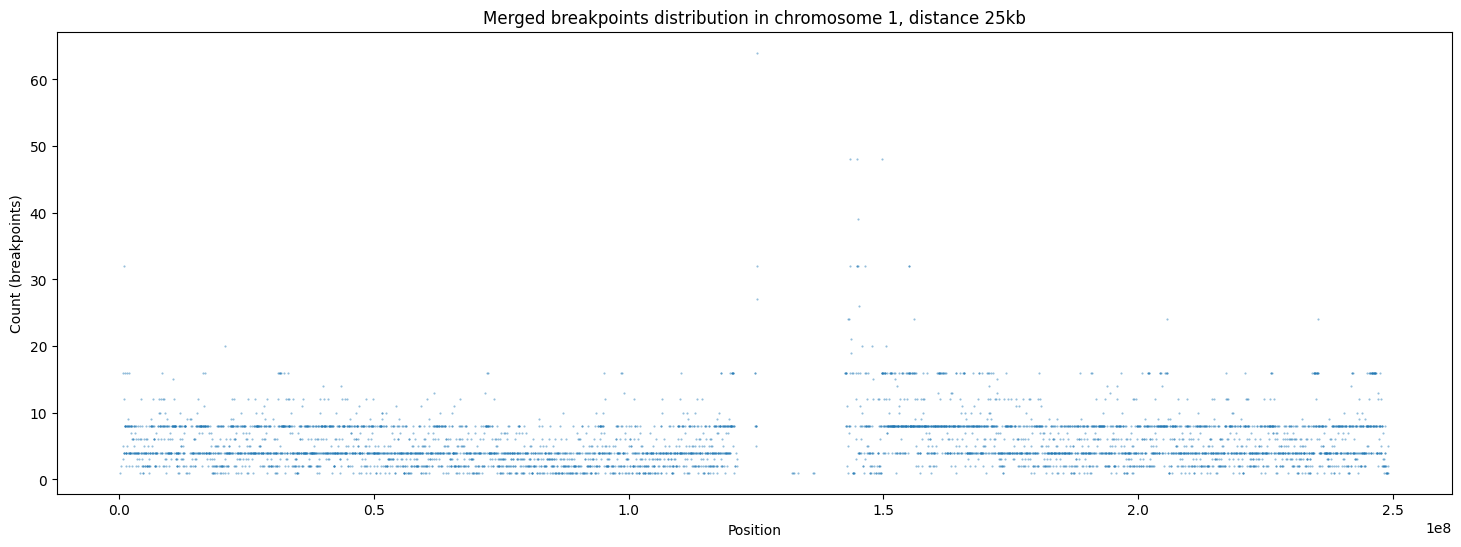

In [4]:
clusters = breaks_to_clusters(dict_start["chr1"])
merged_clusters = merge_clusters(clusters, 25000)

# set image size to 18x3
plt.figure(figsize=(18, 6))
plt.scatter(merged_clusters[:, 0], merged_clusters[:, 1], s=.25, alpha=0.5)
plt.xlabel("Position")
plt.ylabel("Count (breakpoints)")
plt.title("Merged breakpoints distribution in chromosome 1, distance 25kb")

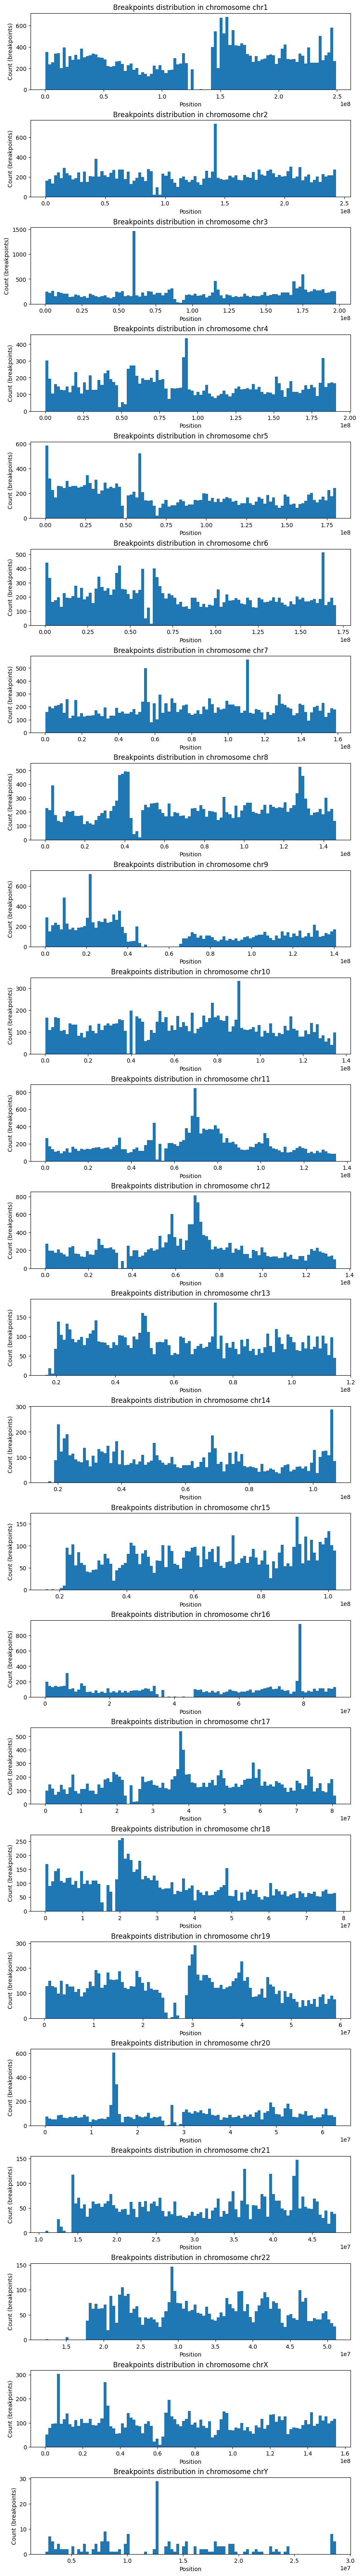

In [5]:
fig, axs = plt.subplots(24, figsize=(10, 80))
# increase space between subplots
plt.subplots_adjust(hspace=.4)
for i, chr in enumerate(hg19.chr_names):
	axs[i].hist(dict_start[chr], bins=100);
	axs[i].set_title(f"Breakpoints distribution in chromosome {chr}")
	axs[i].set_xlabel("Position")
	axs[i].set_ylabel("Count (breakpoints)")

In [6]:
import time
chr_clusters = {}
orig_count = sum(len(values) for values in dict_start.values())
print(f"Reducing {orig_count} breakpoints:")
distances =  [1000, 3000, 10000, 30000, 100000, 300000, 1000000]
counts = []
for dist in distances:
    time_start = time.time()
    
    res = created_merged_segs(dict_start, dist, hg19)
    counts.append(len(res) - len(dict_start))
    reduction = np.round(counts[-1] / orig_count * 100, 2)
    print(f"Dist: {dist}, count: {counts[-1]}, ratio: {reduction}%, time: {time.time() - time_start:.2f}s")

Reducing 329160 breakpoints:
Dist: 1000, count: 276402, ratio: 83.97%, time: 14.64s
Dist: 3000, count: 215124, ratio: 65.36%, time: 21.85s
Dist: 10000, count: 121666, ratio: 36.96%, time: 12.02s
Dist: 30000, count: 53610, ratio: 16.29%, time: 2.71s
Dist: 100000, count: 18436, ratio: 5.6%, time: 1.06s
Dist: 300000, count: 6412, ratio: 1.95%, time: 0.58s
Dist: 1000000, count: 1944, ratio: 0.59%, time: 0.44s


Text(0.5, 1.0, 'Breakpoint reduction by distance')

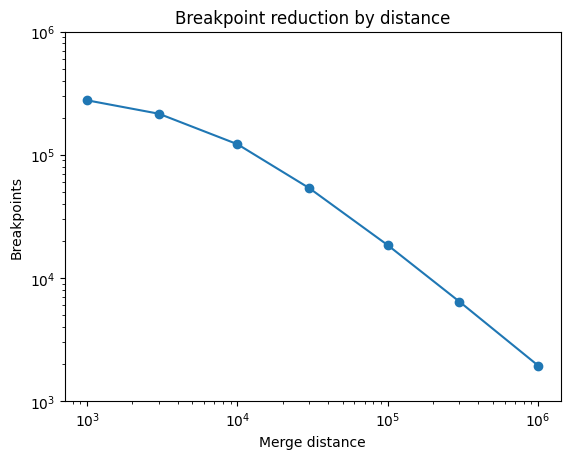

In [7]:
plt.plot(distances, counts, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e3, 1e6)
plt.xlabel('Merge distance')
plt.ylabel('Breakpoints')
plt.title('Breakpoint reduction by distance')